In [1]:
import numpy as np

from matplotlib import pyplot as plt
font = {'family' : 'arial',
        'weight' : 'normal',
        'size'   : 16}
import matplotlib as mpl
mpl.rc('font', **font)
%config InlineBackend.figure_format = 'retina'
cmap = plt.get_cmap('RdBu_r')
# %matplotlib widget
%matplotlib inline

from qutip import (Qobj, tensor, basis, fock, ket, num, qeye, destroy, fidelity, expect, 
                   ket2dm, mesolve, identity, sigmax, sigmay, sigmaz, bra, displace)
from qutip.visualization import plot_fock_distribution, matrix_histogram
                  
font = {'family' : 'Arial',
        'weight' : 'normal',
        'size'   : 16}

np.set_printoptions(suppress=True)
from qutip.visualization import hinton
from tqdm import tqdm
import qutip as qt
import itertools
import seaborn as sns

In [2]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
def enhanced_hinton(qobj, ax, colormap='twilight_shifted', title=None, max_cutoff=0.3):
    """
    Enhanced Hinton plot with automatic dimension detection and labeling.
    X-axis labels are rotated 90 degrees for compactness.
    
    Parameters:
    -----------
    qobj : qutip.Qobj
        Quantum object to visualize
    ax : matplotlib.axes
        Axes to plot on
    colormap : str
        Colormap name for phase representation
    title : str
        Title for the plot
    max_cutoff : float
        Amplitudes above this value will all have the same box size
    """
    # Extract data matrix
    if isinstance(qobj, qt.Qobj):
        data = qobj.full()
    else:
        data = np.asarray(qobj)
    
    n = data.shape[0]
    
    # Automatically determine number of qubits
    num_qubits = int(np.log2(n) + 0.5)  # Round to nearest integer
    
    # Calculate amplitude and phase
    amplitude = np.abs(data)
    phase = np.angle(data)
    
    # Apply cutoff to amplitudes
    max_amp = np.max(amplitude)
    normalized_amp = amplitude / max_amp
    
    # Apply the cutoff
    normalized_amp[normalized_amp > max_cutoff] = max_cutoff
    
    # Scale to maximum box size
    max_size = 0.8
    normalized_amp = normalized_amp * (max_size / max_cutoff)
    
    # Clear the axes first
    ax.clear()
    
    # Use a cyclic colormap
    cmap = plt.get_cmap(colormap)
    
    # Loop through the matrix elements
    for i in range(n):
        for j in range(n):
            size = normalized_amp[i, j]
            if size > 0.01:  # Only plot significant amplitudes
                # Normalize phase from [-π, π] to [0, 1]
                norm_phase = (phase[i, j] + np.pi) / (2 * np.pi)
                color = cmap(norm_phase)
                
                # Create rectangle
                rect = plt.Rectangle([j - size/2, i - size/2], 
                                     size, size,
                                     facecolor=color, edgecolor='black')
                ax.add_patch(rect)
    
    # Set the limits and aspect ratio
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(-0.5, n - 0.5)
    ax.invert_yaxis()  # To match matrix notation
    ax.set_aspect('equal', 'box')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Add phase colorbar
    norm = plt.matplotlib.colors.Normalize(0, 2*np.pi)
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, ticks=[0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    cbar.set_label('Phase (radians)')
    cbar.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
    
    # Generate basis labels based on number of qubits
    basis_labels = []
    for i in range(n):
        # Convert to binary representation with leading zeros
        binary = format(i, f'0{num_qubits}b')
        # Create ket notation
        basis_labels.append(f"|{binary}>")
    
    # Set y tick labels (basis states on y-axis)
    ax.set_yticks(range(len(basis_labels)))
    ax.set_yticklabels(basis_labels)
    
    # Set x tick labels (rotated 90 degrees for compactness)
    ax.set_xticks(range(len(basis_labels)))
    ax.set_xticklabels(basis_labels, rotation=90, ha='center', va='top')
    
    # Add some padding at the bottom for rotated labels
    plt.subplots_adjust(bottom=0.15)
    
    # Add title if provided
    if title:
        ax.set_title(title)
    
    # # Add a small legend for the cutoff
    # ax.text(0.95, 0.05, f"{num_qubits} qubits\nCutoff: {max_cutoff:.2f}", 
    #         transform=ax.transAxes, horizontalalignment='right',
    #         bbox=dict(facecolor='white', alpha=0.7))
    
    return ax

# Test sequence 1 BS-Controlled Parity-BS

In [3]:
def BSCBS(params, tlist, psi0, progbar=True, decoherence=False):
    # C1-C2-Q
    # BS between C1C2, parity wait between C2-Q, BS between C1C2
    # assume we have three different chis for each chis: [idle, strong, tuning]

    N_c, N_q = params['c_dim'], params['q_dim']  # cavity and qubit dimension
    chi_21 = params['chi_21']  # each chi is a float
    g2 = params['g2'] # BS rate to use for C1-C2

    alpha1 = params['alpha1'] # qubit anharmonicity
    # det2 = params['det2'] # detuning
    
    a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
    a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
    a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
                  
    zq1 = a_q1.dag()*a_q1
    zc1, zc2 = a_c1.dag()*a_c1, a_c2.dag()*a_c2

    # define four types of ideal Hamiltonian
   
    H0 =  alpha1/2*a_q1.dag()*a_q1.dag()*a_q1*a_q1
    # swap Hamiltonian
    H1 = g2/2*(1j*a_c1.dag()*a_c2-1j*a_c1*a_c2.dag())
    # Hd = det2*zc2   # detuning

    # ZZ cancellation tone
    # Hzz = det1*zc2*zc2 + g2/2*(a_c2.dag()*a_q1+a_c2*a_q1.dag())

    # chi shift
    H1_chi = chi_21*zc2*zq1
    H2_chi = chi_21*zc2*zq1

    # define the time-dependence of the hamiltonian using the list-string format
    args = {}       
    c_ops = []
    observables = []

    if decoherence:
        Gamma1_c = params['Gamma1_c']
        Gamma1_q = params['Gamma1_q']
        Gamma_phi_c = params['Gamma_phi_c']
        Gamma_phi_q = params['Gamma_phi_q']

        if Gamma1_c > 0:
            c_ops.append(np.sqrt(Gamma1_c)*a_c1.dag()*a_c1)
            c_ops.append(np.sqrt(Gamma1_c)*a_c2.dag()*a_c2)
        if Gamma1_q > 0:
            c_ops.append(np.sqrt(Gamma1_q)*a_q1.dag()*a_q1)
        if Gamma_phi_c > 0:
            c_ops.append(np.sqrt(Gamma_phi_c)*zc1.dag()*zc1)
            c_ops.append(np.sqrt(Gamma_phi_c)*zc2.dag()*zc2)
        if Gamma_phi_q > 0:
            c_ops.append(np.sqrt(Gamma_phi_q)*zq1.dag()*zq1)

    # period 1
    Ht = [H0 + H1]
    tlist_now = tlist[0]
    # print('=========Period1=========')
    output1 = mesolve(Ht, psi0, tlist_now, c_ops, observables, args)

    # period 2
    Ht = [H0 + H1_chi]
    tlist_now = tlist[1]
    # print('=========Period1=========')
    output2 = mesolve(Ht, output1.states[-1], tlist_now, c_ops, observables, args)

    # period 3
    Ht = [H0 - H1]
    tlist_now = tlist[2]
    # print('=========Period1=========')
    output3 = mesolve(Ht, output2.states[-1], tlist_now, c_ops, observables, args)

    # period 4
    Ht = [H0 + H2_chi]
    tlist_now = tlist[3]
    # print('=========Period1=========')
    output4 = mesolve(Ht, output3.states[-1], tlist_now, c_ops, observables, args)

    # apply the virtual Z rotation on one cavity
    

    return output4.states[-1]

In [4]:
# all units in MHz
N_c, N_q = 8,2
chi_21 = -0.7*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 1*2*np.pi

tlist1 = np.linspace(0, np.pi/g2/2, 501)
tlist2 = np.linspace(np.pi/g2/2, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)+np.pi/g2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2, np.abs(np.pi/chi_21)*2+np.pi/g2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
dims = [N_c, N_c, N_q]
psi0 = tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,0))+tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,1))
# psi0 = tensor(basis(N_c,4)+1j*basis(N_c,3),basis(N_c,1)+1j*basis(N_c,2),basis(N_q,1))
psi0 = psi0.unit()

psif = BSCBS(circuit_params1, tlist, psi0, progbar=True)

# ideal gate
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cswap = (np.pi/2*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [5]:
import qutip as qt

# def rand_ket_cav_cutoff_embed(Nc, Nd, Nq):
#     assert 1 <= Nd <= Nc
#     # 1) Haar-random in the subspace [Nd, Nd, Nq]
#     psi_sub = qt.rand_ket([Nd, Nd, Nq])

#     # 2) Isometric embedding Nd -> Nc for a cavity
#     #    E maps |0..Nd-1>_small to |0..Nd-1>_big (rest zero)
#     E = qt.Qobj(np.vstack([np.eye(Nd), np.zeros((Nc-Nd, Nd))]), dims=[[Nc], [Nd]])

#     # 3) Embed to full space [Nc, Nc, Nq]
#     embed = qt.tensor(E, E, qt.qeye(Nq))
#     psi_full = embed * psi_sub     # already normalized (isometry)
#     # psi_full.dims == [[Nc, Nc, Nq], [1, 1, 1]]
#     return psi_full

def rand_ket_cav_cutoff_embed(Nc: int, Nd: int, Nq: int, rng=None) -> qt.Qobj:
    """
    Haar-random pure state in the subspace:
      S = span{ |n1>|n2>|q> : n1+n2 = Nd, 0<=n1,n2<Nc, 0<=q<Nq }.
    Returns a ket with dims [[Nc, Nc, Nq], [1,1,1]].
    """
    assert Nc >= 1 and Nq >= 1
    # Valid (n1,n2) pairs with total = Nd and within cutoff
    n1_min = max(0, Nd - (Nc - 1))
    n1_max = min(Nc - 1, Nd)
    pairs = [(n1, Nd - n1) for n1 in range(n1_min, n1_max + 1)
             if 0 <= Nd - n1 < Nc]

    if not pairs:
        raise ValueError(f"No (n1,n2) within cutoff Nc={Nc} have n1+n2=Nd={Nd}. "
                         f"Require 0 <= Nd <= 2*(Nc-1).")

    if rng is None:
        rng = np.random.default_rng()

    # Dimension of the constrained subspace = (#pairs) * Nq
    D = len(pairs) * Nq

    # Haar on the subspace: complex Gaussian then normalize
    coeffs = rng.normal(size=D) + 1j * rng.normal(size=D)
    coeffs = coeffs / np.linalg.norm(coeffs)

    # Build the state as a linear combination of subspace basis vectors
    psi = None
    k = 0
    for (n1, n2) in pairs:
        for q in range(Nq):
            basis_vec = qt.tensor(qt.basis(Nc, n1), qt.basis(Nc, n2), qt.basis(Nq, q))
            psi = coeffs[k] * basis_vec if psi is None else psi + coeffs[k] * basis_vec
            k += 1

    # psi is already normalized by construction
    return psi

## Check fidelity

In [6]:
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
Cswap = (np.pi/2*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50
fid_list = []
for i in range(num):
    psi_sub = rand_ket_cav_cutoff_embed(N_c, 4, N_q)  # returns a ket with composite dimensions
    psif = (BSCBS(circuit_params1, tlist, psi_sub, progbar=False)).unit()
    psi_ideal = (Cswap * psi_sub).unit()
    fid_list.append(fidelity(psif, psi_ideal)**2)

In [7]:
fid_list

[0.9999999657119617,
 0.999999957986041,
 0.9999999985390642,
 0.9999999733356786,
 0.9999999807718419,
 0.9999999554084062,
 0.9999999623429136,
 0.9999999723737307,
 0.9999999698615756,
 0.999999982567367,
 0.9999999951752865,
 0.9999999852346304,
 0.9999999665266107,
 0.9999999918563511,
 0.9999999858374435,
 0.9999999852594896,
 0.9999999410779834,
 0.9999999808877881,
 0.999999990754004,
 0.9999999923563252,
 0.9999999780678989,
 0.9999999526254012,
 0.9999999803107348,
 0.9999999699951454,
 0.9999999658692772,
 0.9999999911704476,
 0.9999999798040343,
 0.9999999797449789,
 0.999999977829164,
 0.9999999745237204,
 0.9999999560655137,
 0.9999999404145572,
 0.999999976172481,
 0.9999999657615203,
 0.9999999637846962,
 0.9999999874204457,
 0.9999999459846415,
 0.9999999839013888,
 0.9999999806082301,
 0.9999999455089535,
 0.9999999824628493,
 0.9999999537099774,
 0.9999999780133643,
 0.9999999662634734,
 0.9999999847830207,
 0.9999999838080939,
 0.9999999517178745,
 0.999999979140701

In [134]:
# with decoherence
# all units in MHz
N_c, N_q = 8,2
chi_21 = -0.7*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 1*2*np.pi

T1_c = 500
T1_q = 150
Tphi_c = 2000
Tphi_q = 400

tlist1 = np.linspace(0, np.pi/g2/2, 501)
tlist2 = np.linspace(np.pi/g2/2, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)+np.pi/g2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2, np.abs(np.pi/chi_21)*2+np.pi/g2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
circuit_params1['Gamma1_c'] = 1/T1_c
circuit_params1['Gamma1_q'] = 1/T1_q
circuit_params1['Gamma_phi_c'] = 1/Tphi_c
circuit_params1['Gamma_phi_q'] = 1/Tphi_q
dims = [N_c, N_c, N_q]
# psi0 = tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,0))+tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,1))
psi0 = tensor(basis(N_c,4)+1j*basis(N_c,3),basis(N_c,1)+1j*basis(N_c,2),basis(N_q,0))
psi0 = psi0.unit()

psif = BSCBS(circuit_params1, tlist, psi0, progbar=True, decoherence=True)

# ideal gate
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cswap = (np.pi/2*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()

In [137]:
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
Cswap = (np.pi/2*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50
fid_list = []
for i in range(num):
    psi_sub = rand_ket_cav_cutoff_embed(N_c, 4, N_q)  # returns a ket with composite dimensions
    psif = (BSCBS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
    psi_ideal = (Cswap * psi_sub).unit()
    fid_list.append(fidelity(psif, psi_ideal)**2)

In [138]:
fid_list

[0.9202118954450553,
 0.9186366901371158,
 0.8969117222011485,
 0.9151819048479377,
 0.8890220165414908,
 0.9388937329038931,
 0.9410639095056124,
 0.9092549564147918,
 0.9140395987264054,
 0.8939875921533333,
 0.9307363423618258,
 0.9243010034056962,
 0.9271062916265558,
 0.9365592527642945,
 0.914510152041271,
 0.9041838238597261,
 0.9458751314800439,
 0.9155136478640029,
 0.9294124738435136,
 0.9346913227635191,
 0.9244166201756424,
 0.9049019308404865,
 0.9125314162545731,
 0.9225649754671096,
 0.8882628663125514,
 0.9120517945225164,
 0.915720435928791,
 0.9118492742398384,
 0.9463304566980398,
 0.9288072884661591,
 0.8935145986698938,
 0.8782502042377693,
 0.9289147271148067,
 0.9048179200236648,
 0.9059347905127006,
 0.9424248292850755,
 0.9392786975559093,
 0.910059585270672,
 0.9202519669202951,
 0.9188197213824958,
 0.927636477220269,
 0.9277276008149414,
 0.9044741643633228,
 0.9080692123399502,
 0.930678046371851,
 0.8898825225128206,
 0.9250377397358475,
 0.935549195401605

In [139]:
print('fidelity ',np.average(fid_list),'+-',np.std(fid_list))

fidelity  0.9187605179234939 +- 0.0166362665147544


In [142]:
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
circuit_params1['Gamma1_c'] = 1/T1_c
circuit_params1['Gamma1_q'] = 1/T1_q
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
Cswap = (np.pi/2*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50
fid_list = []
for i in range(num):
    psi_sub = rand_ket_cav_cutoff_embed(N_c, 4, N_q)  # returns a ket with composite dimensions
    psif = (BSCBS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
    psi_ideal = (Cswap * psi_sub).unit()
    fid_list.append(fidelity(psif, psi_ideal)**2)

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [143]:
print('fidelity ',np.average(fid_list),'+-',np.std(fid_list))

fidelity  0.9220160031718219 +- 0.015443082011941266


# Now check Controlled BS, instead of a controlled Swap

Very likely, the gate sequence is BS/4, parity, BS/4, parity

In [144]:
def controlled_BS(params, tlist, psi0, progbar=True, decoherence=False):
    # C1-C2-Q
    # BS between C1C2, parity wait between C2-Q, BS between C1C2
    # assume we have three different chis for each chis: [idle, strong, tuning]

    N_c, N_q = params['c_dim'], params['q_dim']  # cavity and qubit dimension
    chi_21 = params['chi_21']  # each chi is a float
    g2 = params['g2'] # BS rate to use for C1-C2

    alpha1 = params['alpha1'] # qubit anharmonicity
    # det2 = params['det2'] # detuning
    
    a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
    a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
    a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
                  
    zq1 = a_q1.dag()*a_q1
    zc1, zc2 = a_c1.dag()*a_c1, a_c2.dag()*a_c2

    # define four types of ideal Hamiltonian
   
    H0 =  alpha1/2*a_q1.dag()*a_q1.dag()*a_q1*a_q1
    # swap Hamiltonian
    H1 = g2/2*(1j*a_c1.dag()*a_c2-1j*a_c1*a_c2.dag())
    # Hd = det2*zc2   # detuning

    # ZZ cancellation tone
    # Hzz = det1*zc2*zc2 + g2/2*(a_c2.dag()*a_q1+a_c2*a_q1.dag())

    # chi shift
    H1_chi = chi_21*zc2*zq1
    H2_chi = chi_21*zc2*zq1

    # define the time-dependence of the hamiltonian using the list-string format
    args = {}       
    c_ops = []
    observables = []

    if decoherence:
        Gamma1_c = params['Gamma1_c']
        Gamma1_q = params['Gamma1_q']
        Gamma_phi_c = params['Gamma_phi_c']
        Gamma_phi_q = params['Gamma_phi_q']

        if Gamma1_c > 0:
            c_ops.append(np.sqrt(Gamma1_c)*a_c1.dag()*a_c1)
            c_ops.append(np.sqrt(Gamma1_c)*a_c2.dag()*a_c2)
        if Gamma1_q > 0:
            c_ops.append(np.sqrt(Gamma1_q)*a_q1.dag()*a_q1)
        if Gamma_phi_c > 0:
            c_ops.append(np.sqrt(Gamma_phi_c)*zc1.dag()*zc1)
            c_ops.append(np.sqrt(Gamma_phi_c)*zc2.dag()*zc2)
        if Gamma_phi_q > 0:
            c_ops.append(np.sqrt(Gamma_phi_q)*zq1.dag()*zq1)

    # period 1
    Ht = [H0 + H1]
    tlist_now = tlist[0]
    # print('=========Period1=========')
    output1 = mesolve(Ht, psi0, tlist_now, c_ops, observables, args)

    # period 2
    Ht = [H0 + H1_chi]
    tlist_now = tlist[1]
    # print('=========Period1=========')
    output2 = mesolve(Ht, output1.states[-1], tlist_now, c_ops, observables, args)

    # period 3
    Ht = [H0 - H1]
    tlist_now = tlist[2]
    # print('=========Period1=========')
    output3 = mesolve(Ht, output2.states[-1], tlist_now, c_ops, observables, args)

    # period 4
    Ht = [H0 + H2_chi]
    tlist_now = tlist[3]
    # print('=========Period1=========')
    output4 = mesolve(Ht, output3.states[-1], tlist_now, c_ops, observables, args)

    # apply the virtual Z rotation on one cavity
    

    return output4.states[-1]

In [148]:
# with decoherence
# all units in MHz
N_c, N_q = 10,2
chi_21 = -0.7*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 1*2*np.pi

T1_c = 500
T1_q = 150
Tphi_c = 2000
Tphi_q = 400

tlist1 = np.linspace(0, np.pi/g2/4, 501)
tlist2 = np.linspace(np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/4, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)*2+np.pi/g2/2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
circuit_params1['Gamma1_c'] = 1/T1_c
circuit_params1['Gamma1_q'] = 1/T1_q
circuit_params1['Gamma_phi_c'] = 1/Tphi_c
circuit_params1['Gamma_phi_q'] = 1/Tphi_q
dims = [N_c, N_c, N_q]
psi0 = tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,0))+tensor(basis(N_c,4)+basis(N_c,3),basis(N_c,1)+basis(N_c,2),basis(N_q,1))
# psi0 = tensor(basis(N_c,4)+1j*basis(N_c,3),basis(N_c,1)+1j*basis(N_c,2),basis(N_q,1))
psi0 = psi0.unit()

psif = controlled_BS(circuit_params1, tlist, psi0, progbar=True, decoherence=False)

# ideal gate
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cbs = (np.pi/4*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [149]:
a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cbs = (np.pi/4*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50
fid_list = []
for i in range(num):
    psi_sub = rand_ket_cav_cutoff_embed(N_c, 4, N_q)  # returns a ket with composite dimensions
    psif = (controlled_BS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
    psi_ideal = (Cbs * psi_sub).unit()
    fid_list.append(fidelity(psif, psi_ideal)**2)

c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(


In [150]:
print('fidelity ',np.average(fid_list),'+-',np.std(fid_list))

fidelity  0.9360553625095135 +- 0.012902116647690516


In [193]:
# Parameters
Nc, Nd, Nq = 3, 4, 2
psi_full = rand_ket_cav_cutoff_embed(Nc, Nd, Nq)

# --- Define photon number operators for both cavities ---
a1_num = qt.tensor(qt.destroy(Nc), qt.qeye(Nc), qt.qeye(Nq))
a2_num = qt.tensor(qt.qeye(Nc), qt.destroy(Nc), qt.qeye(Nq))

nn1 = a1_num.dag() * a1_num
nn2 = a2_num.dag() * a2_num

photon1 = expect(nn1, psi_full)
photon2 = expect(nn2, psi_full)
print(f"Initial photon number in cavity 1: {photon1:.2f}")
print(f"Initial photon number in cavity 2: {photon2:.2f}")
print(f"total photon number: {photon1+photon2:.2f}")


Initial photon number in cavity 1: 2.00
Initial photon number in cavity 2: 2.00
total photon number: 4.00


In [194]:
psi_full

Quantum object: dims=[[3, 3, 2], [1, 1, 1]], shape=(18, 1), type='ket', dtype=Dense
Qobj data =
[[0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.        +0.j        ]
 [0.10439754+0.94391931j]
 [0.29509205+0.10506272j]]

### With all noise, check fidelity vs total photon number

In [195]:
N_c, N_q = 13,2
chi_21 = -0.7*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 1*2*np.pi

T1_c = 500
T1_q = 150
Tphi_c = 2000
Tphi_q = 400

tlist1 = np.linspace(0, np.pi/g2/4, 501)
tlist2 = np.linspace(np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/4, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)*2+np.pi/g2/2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
circuit_params1['Gamma1_c'] = 1/T1_c
circuit_params1['Gamma1_q'] = 1/T1_q
circuit_params1['Gamma_phi_c'] = 1/Tphi_c
circuit_params1['Gamma_phi_q'] = 1/Tphi_q
dims = [N_c, N_c, N_q]

total_photon_list = [1,2,3,4,5,6]

a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cbs = (np.pi/4*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50

all_infid_list = []

for nn in total_photon_list:
    infid_list = []
    for i in tqdm(range(num)):
        psi_sub = rand_ket_cav_cutoff_embed(N_c, nn, N_q)  # returns a ket with composite dimensions
        psif = (controlled_BS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
        psi_ideal = (Cbs * psi_sub).unit()
        infid_list.append(1-fidelity(psif, psi_ideal)**2)
    all_infid_list.append(infid_list)



  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(
100%|██████████| 50/50 [03:49<00:00,  4.58s/it]


C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3431029233.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3431029233.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3431029233.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3431029233.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3431029233.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_s

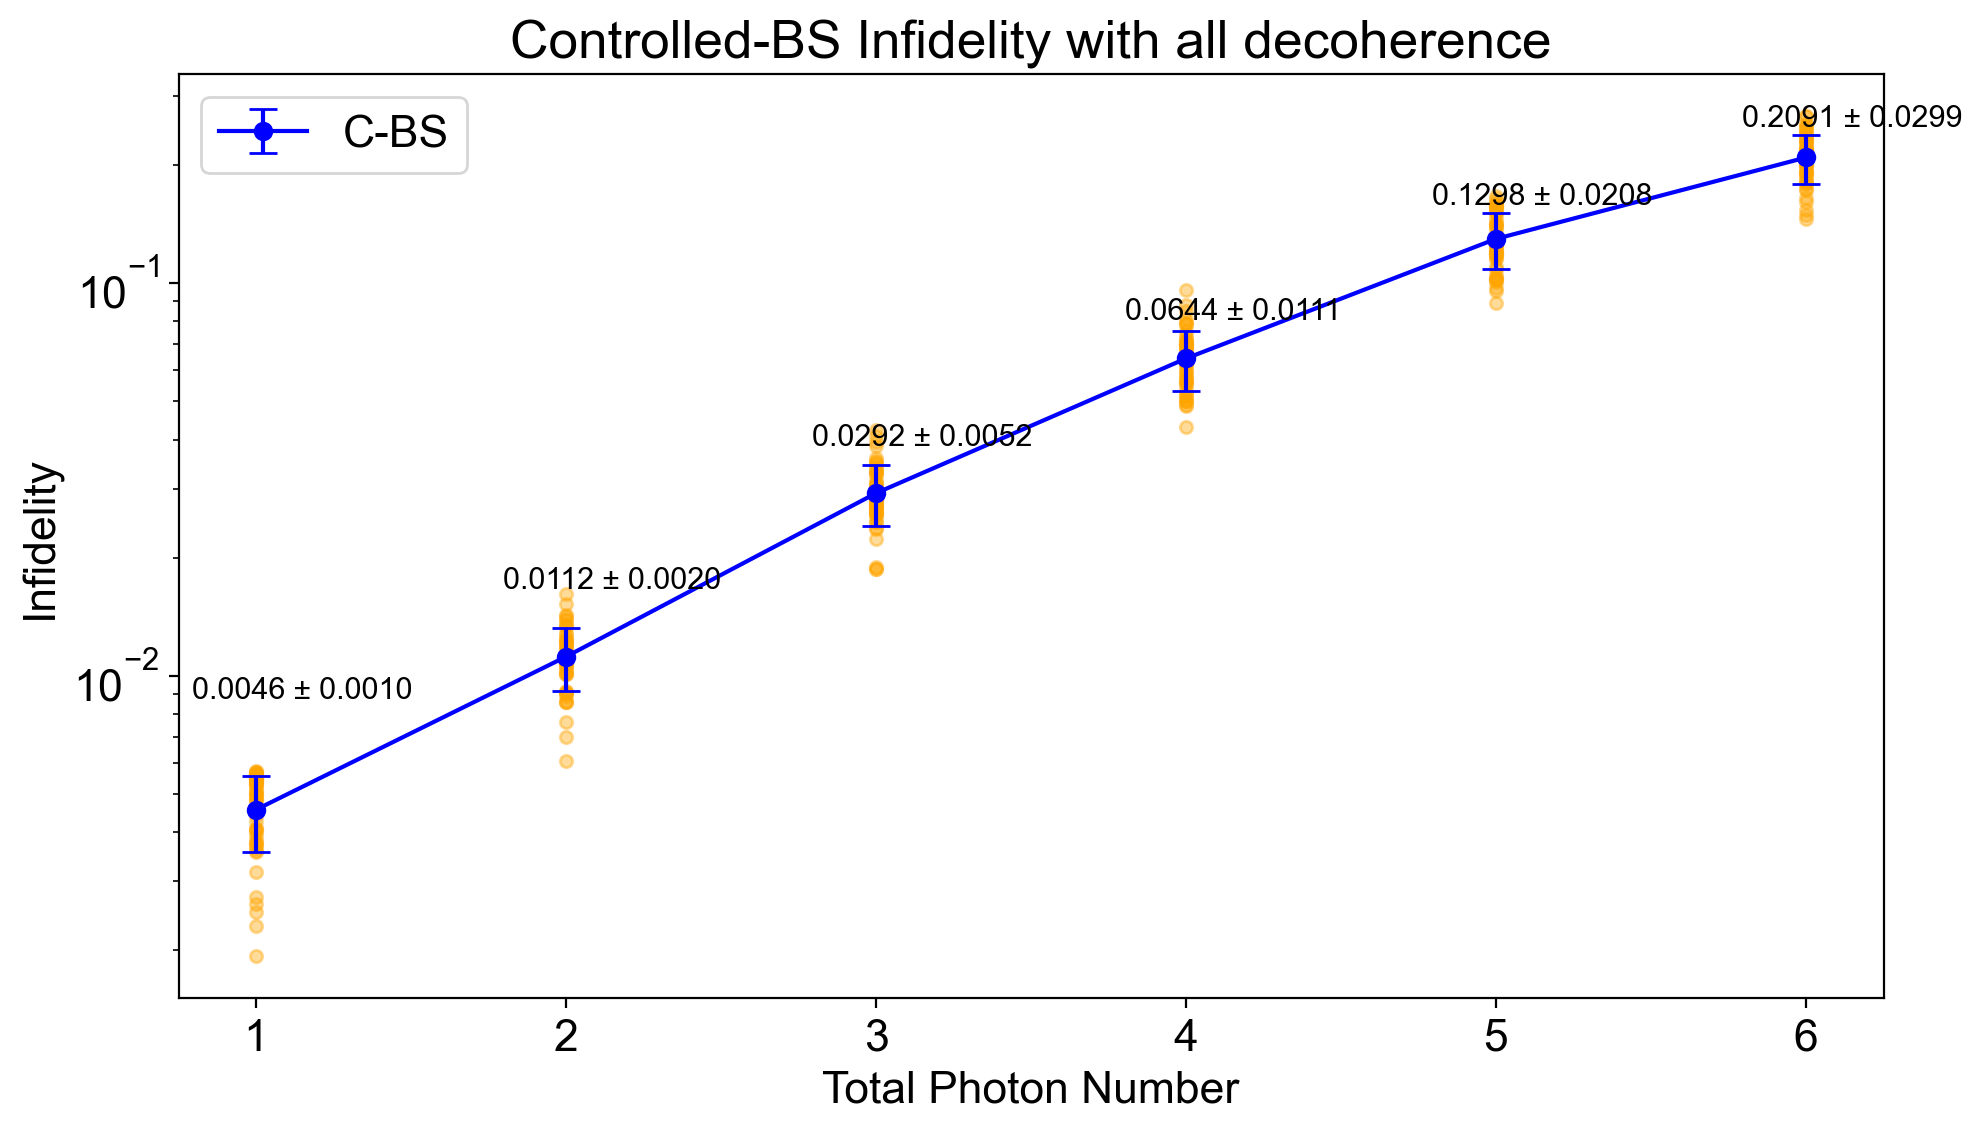

In [214]:
means = np.mean(all_infid_list, axis=1)
stds = np.std(all_infid_list, axis=1)
x = total_photon_list
plt.figure(figsize=(11, 6))

# Plot mean with error bars
plt.errorbar(x, means, yerr=stds, fmt='-o', capsize=5, label='C-BS', color='blue')

# Overlay all data points and density
for i, values in enumerate(all_infid_list):
    sns.kdeplot(
        x=[x[i]]*len(values),
        y=values,
        fill=True,
        cmap="Blues",
        bw_adjust=0.4,
        alpha=0.5,
        linewidth=0
    )
    plt.scatter([x[i]]*len(values), values, color='orange', alpha=0.4, s=20)

# Add text labels (mean ± std)
for xi, mean, std in zip(x, means, stds):
    plt.text(
        xi+0.15, mean + std + stds.mean()*0.25,      # position slightly above the error bar
        f"{mean:.4f} ± {std:.4f}",
        ha='center', va='bottom', fontsize=11, color='black'
    )
plt.yscale('log')

plt.xlabel("Total Photon Number")
plt.ylabel("Infidelity")
plt.title("Controlled-BS Infidelity with all decoherence")
plt.legend()
plt.show()

### dephasing only?

In [216]:
N_c, N_q = 13,2
chi_21 = -0.7*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 1*2*np.pi

T1_c = 500
T1_q = 150
Tphi_c = 2000
Tphi_q = 400

tlist1 = np.linspace(0, np.pi/g2/4, 501)
tlist2 = np.linspace(np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/4, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)*2+np.pi/g2/2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
circuit_params1['Gamma1_c'] = 1/T1_c*0
circuit_params1['Gamma1_q'] = 1/T1_q*0
circuit_params1['Gamma_phi_c'] = 1/Tphi_c
circuit_params1['Gamma_phi_q'] = 1/Tphi_q
dims = [N_c, N_c, N_q]

total_photon_list = [1,2,3,4,5,6]

a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cbs = (np.pi/4*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50

all_infid_list = []

for nn in total_photon_list:
    infid_list = []
    for i in tqdm(range(num)):
        psi_sub = rand_ket_cav_cutoff_embed(N_c, nn, N_q)  # returns a ket with composite dimensions
        psif = (controlled_BS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
        psi_ideal = (Cbs * psi_sub).unit()
        infid_list.append(1-fidelity(psif, psi_ideal)**2)
    all_infid_list.append(infid_list)



100%|██████████| 50/50 [03:32<00:00,  4.24s/it]


C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3552724397.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3552724397.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3552724397.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3552724397.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3552724397.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_s

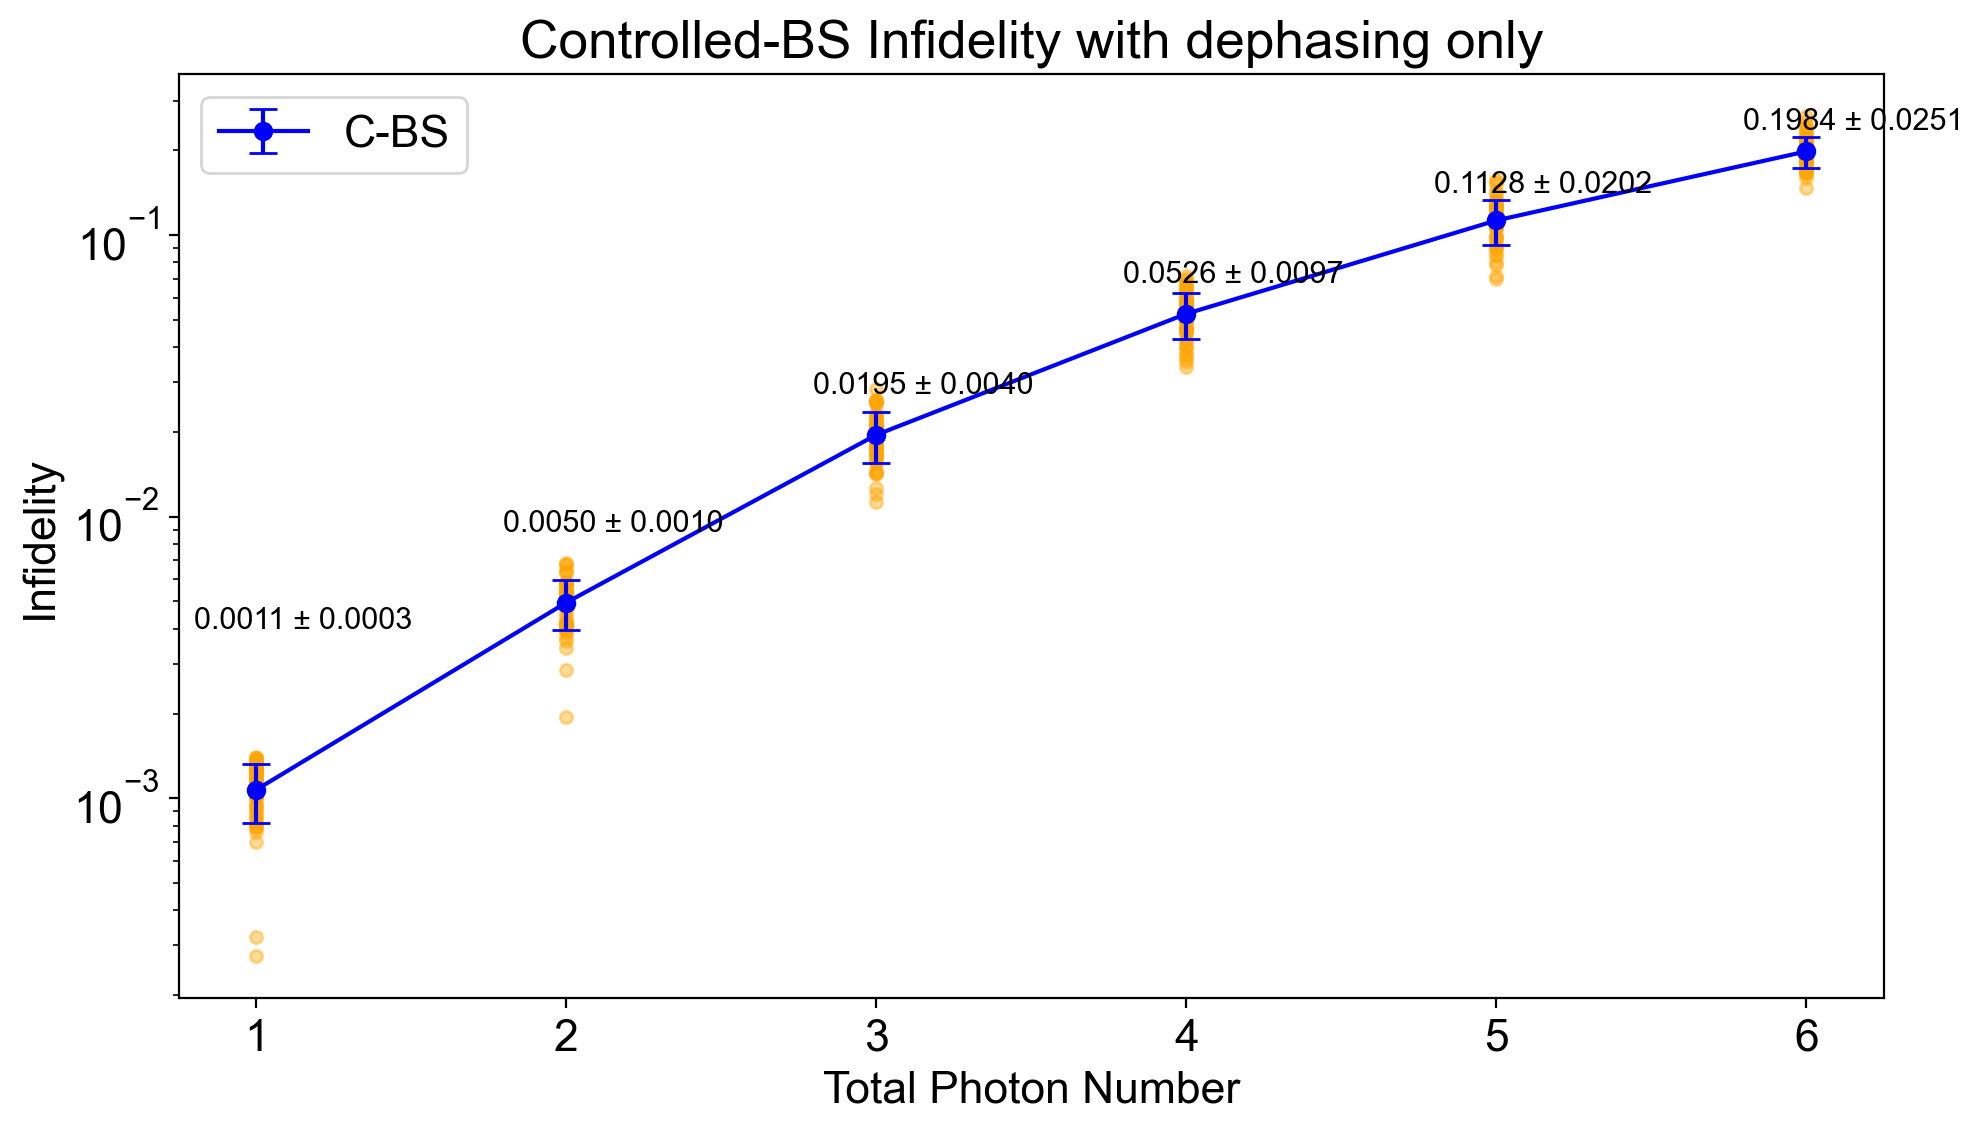

In [217]:
means = np.mean(all_infid_list, axis=1)
stds = np.std(all_infid_list, axis=1)
x = total_photon_list
plt.figure(figsize=(11, 6))

# Plot mean with error bars
plt.errorbar(x, means, yerr=stds, fmt='-o', capsize=5, label='C-BS', color='blue')

# Overlay all data points and density
for i, values in enumerate(all_infid_list):
    sns.kdeplot(
        x=[x[i]]*len(values),
        y=values,
        fill=True,
        cmap="Blues",
        bw_adjust=0.4,
        alpha=0.5,
        linewidth=0
    )
    plt.scatter([x[i]]*len(values), values, color='orange', alpha=0.4, s=20)

# Add text labels (mean ± std)
for xi, mean, std in zip(x, means, stds):
    plt.text(
        xi+0.15, mean + std + stds.mean()*0.25,      # position slightly above the error bar
        f"{mean:.4f} ± {std:.4f}",
        ha='center', va='bottom', fontsize=11, color='black'
    )
plt.yscale('log')

plt.xlabel("Total Photon Number")
plt.ylabel("Infidelity")
plt.title("Controlled-BS Infidelity with dephasing only")
plt.legend()
plt.show()

In [220]:
g2 = 1.0*2*np.pi
chi_21 = -0.7*2*np.pi
np.abs(np.pi/chi_21)*2+np.pi/g2/2

1.6785714285714286

In [ ]:
# what's the fidelity of 10 trotter steps?
infidelity_2Q_layered = np.array([0.0011, 0.0050, 0.0195, 0.0526, 0.1128, 0.1984])
infidelity_1Q_layered = 0.15/1.6785714285714286*infidelity_2Q_layered

depth = 20
final_inf = []

for i in range(len(infidelity_2Q_layered)):
    ff = 1
    for j in range(depth):
        ff = ff*(1-infidelity_2Q_layered[i])*(1-infidelity_1Q_layered[i])
    final_inf.append(1-ff)


In [226]:
final_inf

[0.023692970817771997,
 0.10343905181432222,
 0.3486669245518852,
 0.6911525814936772,
 0.9254525767864574,
 0.991609701351489]

### In the best case

In [218]:
N_c, N_q = 13,2
chi_21 = -1.5*2*np.pi

alpha1 = -125* 2 * np.pi

g2 = 2.5*2*np.pi

T1_c = 750
T1_q = 250
Tphi_c = 4000
Tphi_q = 600

tlist1 = np.linspace(0, np.pi/g2/4, 501)
tlist2 = np.linspace(np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/4, 501)
tlist3 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/4, np.abs(np.pi/chi_21)+np.pi/g2/2, 501)
tlist4 = np.linspace(np.abs(np.pi/chi_21)+np.pi/g2/2, np.abs(np.pi/chi_21)*2+np.pi/g2/2, 501)
tlist = [tlist1, tlist2, tlist3, tlist4]


circuit_params1 = {'q_dim':N_q, 'c_dim': N_c, \
                  'chi_21':chi_21, \
                    'g2':g2, 'alpha1':alpha1}
circuit_params1['Gamma1_c'] = 1/T1_c
circuit_params1['Gamma1_q'] = 1/T1_q
circuit_params1['Gamma_phi_c'] = 1/Tphi_c
circuit_params1['Gamma_phi_q'] = 1/Tphi_q
dims = [N_c, N_c, N_q]

total_photon_list = [1,2,3,4,5,6]

a_c1 = tensor(destroy(N_c), qeye(N_c), qeye(N_q))
a_c2 = tensor(qeye(N_c), destroy(N_c), qeye(N_q))
a_q1 = tensor(qeye(N_c), qeye(N_c), destroy(N_q))
# zq1 = a_q1.dag()*a_q1
ZI = tensor(qeye(N_c), qeye(N_c), basis(2,1)*basis(2,1).dag())
# II = tensor(qeye(N_c), qeye(N_c), basis(2,0)*basis(2,0).dag())
Cbs = (np.pi/4*(ZI)*(a_c1.dag()*a_c2-a_c1*a_c2.dag())).expm()
num = 50

all_infid_list = []

for nn in total_photon_list:
    infid_list = []
    for i in tqdm(range(num)):
        psi_sub = rand_ket_cav_cutoff_embed(N_c, nn, N_q)  # returns a ket with composite dimensions
        psif = (controlled_BS(circuit_params1, tlist, psi_sub, progbar=False,decoherence=True)).unit()
        psi_ideal = (Cbs * psi_sub).unit()
        infid_list.append(1-fidelity(psif, psi_ideal)**2)
    all_infid_list.append(infid_list)



  0%|          | 0/50 [00:00<?, ?it/s]c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
c:\Users\Inline6\anaconda3\envs\in6\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: args will be keyword only from qutip 5.3 for all solver
  warnings.warn(
100%|██████████| 50/50 [03:37<00:00,  4.35s/it]


C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3188858373.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3188858373.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3188858373.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3188858373.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3188858373.py:11: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_s

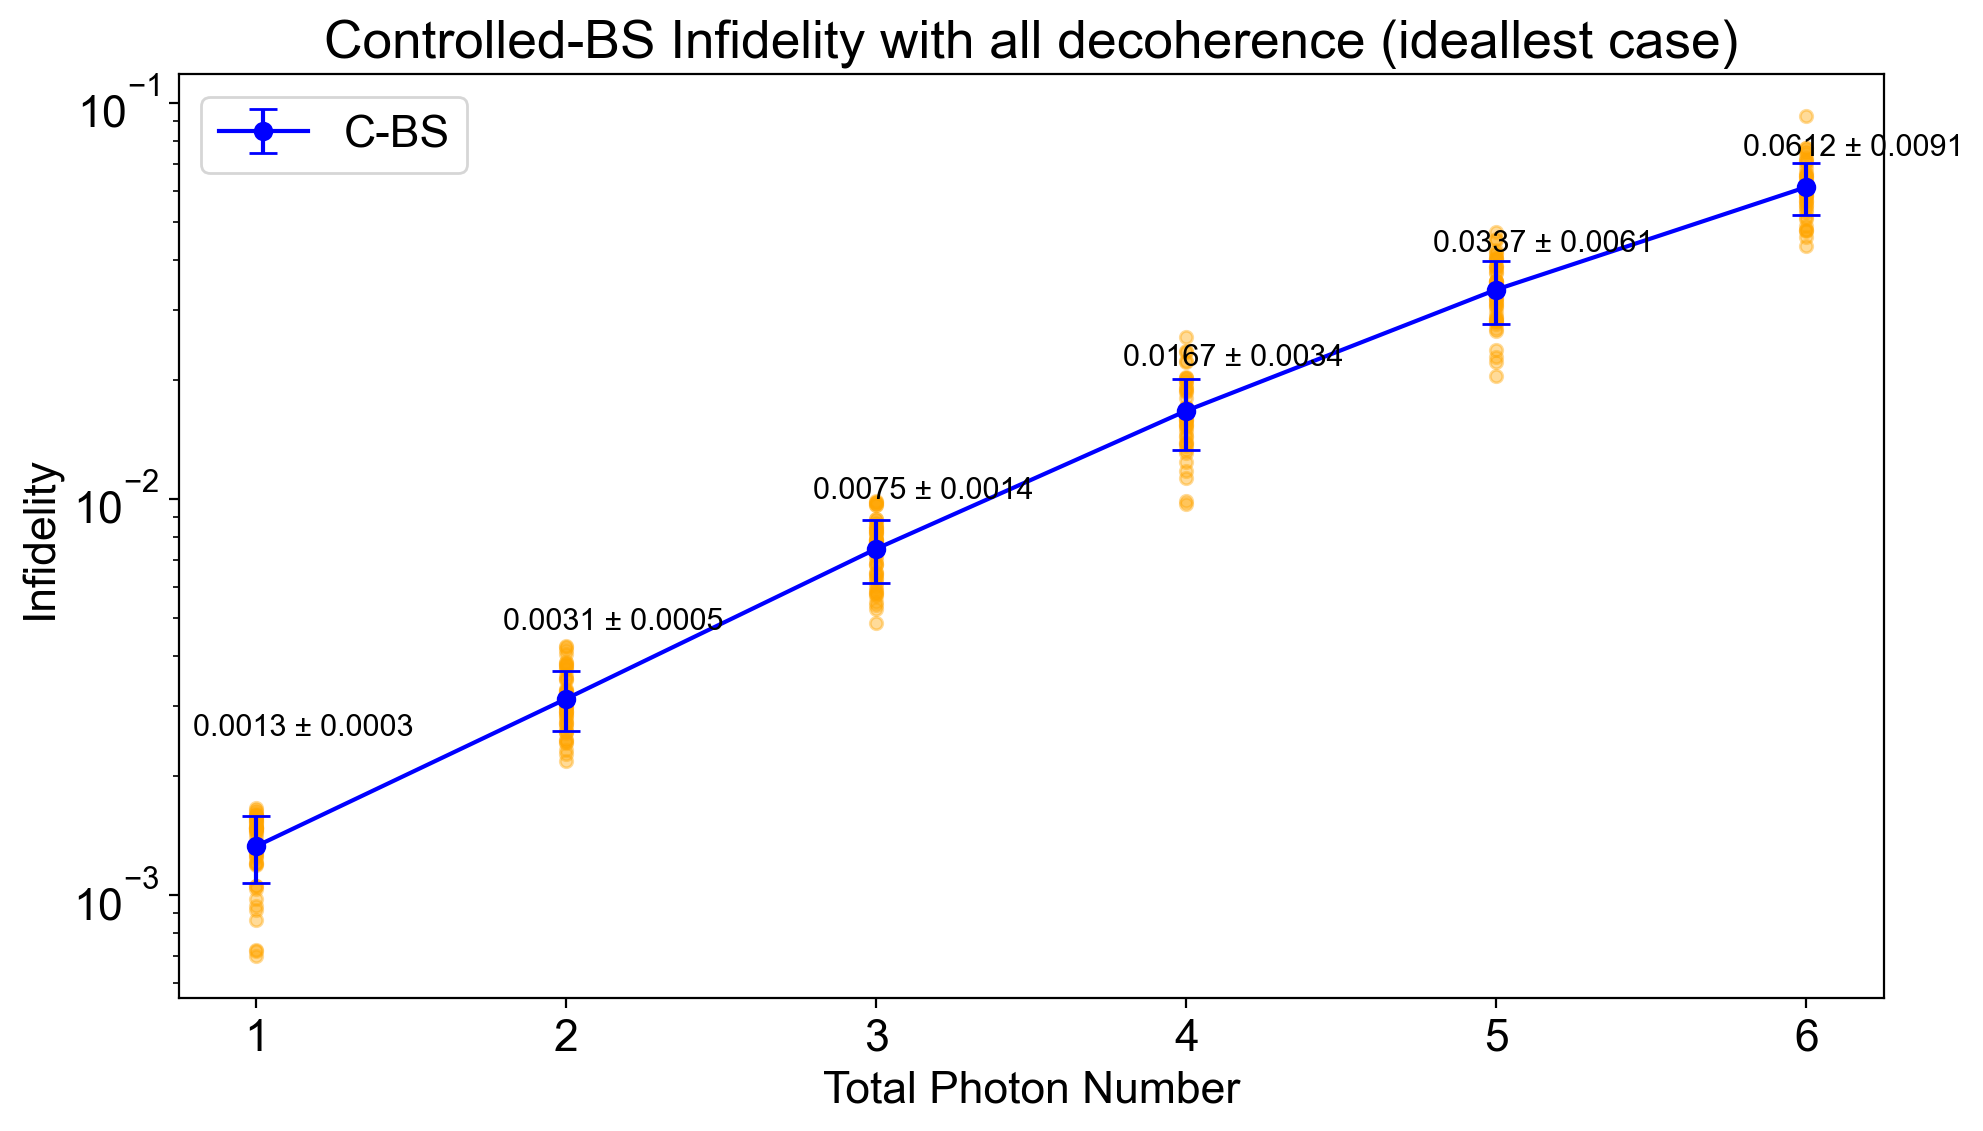

In [219]:
means = np.mean(all_infid_list, axis=1)
stds = np.std(all_infid_list, axis=1)
x = total_photon_list
plt.figure(figsize=(11, 6))

# Plot mean with error bars
plt.errorbar(x, means, yerr=stds, fmt='-o', capsize=5, label='C-BS', color='blue')

# Overlay all data points and density
for i, values in enumerate(all_infid_list):
    sns.kdeplot(
        x=[x[i]]*len(values),
        y=values,
        fill=True,
        cmap="Blues",
        bw_adjust=0.4,
        alpha=0.5,
        linewidth=0
    )
    plt.scatter([x[i]]*len(values), values, color='orange', alpha=0.4, s=20)

# Add text labels (mean ± std)
for xi, mean, std in zip(x, means, stds):
    plt.text(
        xi+0.15, mean + std + stds.mean()*0.25,      # position slightly above the error bar
        f"{mean:.4f} ± {std:.4f}",
        ha='center', va='bottom', fontsize=11, color='black'
    )
plt.yscale('log')

plt.xlabel("Total Photon Number")
plt.ylabel("Infidelity")
plt.title("Controlled-BS Infidelity with all decoherence (ideallest case)")
plt.legend()
plt.show()

# The sequence to simulate a 1D Z2 lattice gauge theory is following

Cswap-->X on all qubits-->Cswap-->X on all qubits
System size: 4 bosons, 3 qubits
N^4*2^3
when N=16 this is huge...
let's try N=4

In [97]:
def gate_cswap(index=0, N_c=4, N_q=2, N_total=4):
    """
    Returns a CSR-sparse Qobj implementing a controlled SWAP between cavities
    C_index and C_{index+1}, controlled by qubit Q_index in |1⟩.

    Ordering: C1..C_Ntotal, Q1..Q_(N_total-1)
    All intermediate operators are kept on the CSR backend to save memory.
    """
    if not (0 <= index <= N_total - 2):
        raise ValueError("index must be in [0, N_total-2].")

    # --- helpers that ALWAYS return CSR-backed Qobj ---
    def eye(dim):
        return qeye(dim).to('csr')

    def eye_chain(count, dim):
        # Tensor of `count` many identities of dimension `dim` (CSR).
        if count <= 0:
            # Return a 1x1 identity on CSR so tensor([... , I1]) is neutral & stays sparse
            return Qobj([[1.0]]).to('csr')
        return tensor([eye(dim) for _ in range(count)]).to('csr')

    def op_destroy(dim):
        return destroy(dim).to('csr')

    def proj_one(dim):
        # |1><1| (CSR)
        ket1 = basis(dim, 1)             # ket is CSR internally
        return (ket1 * ket1.dag()).to('csr')

    def t(*ops):
        # Tensor only the non-trivial factors; keep on CSR.
        seq = []
        for op in ops:
            if isinstance(op, Qobj):
                # If it's a 1x1 identity, skip; otherwise keep
                if not (op.shape == (1, 1) and abs(op.full()[0, 0] - 1.0) < 1e-15):
                    seq.append(op)
        if len(seq) == 0:
            return Qobj([[1.0]]).to('csr')
        if len(seq) == 1:
            return seq[0].to('csr')
        return tensor(seq).to('csr')

    # --- build sparse operators ---

    # a_c1 acts on cavity `index`
    a_c1 = t(
        eye_chain(index, N_c),
        op_destroy(N_c),
        eye_chain(N_total - index - 1, N_c),
        eye_chain(N_total - 1, N_q)
    ).to('csr')

    # a_c2 acts on cavity `index+1`
    a_c2 = t(
        eye_chain(index + 1, N_c),
        op_destroy(N_c),
        eye_chain(N_total - (index + 1) - 1, N_c),
        eye_chain(N_total - 1, N_q)
    ).to('csr')

    # Projector onto |1> of qubit Q_index
    proj_q1 = t(
        eye_chain(N_total, N_c),
        eye_chain(index, N_q),
        proj_one(N_q),
        eye_chain((N_total - 1) - index - 1, N_q)
    ).to('csr')

    # anti-Hermitian generator (CSR) and sparse matrix exponential
    G = (proj_q1 * (a_c1.dag() * a_c2 - a_c1 * a_c2.dag())).to('csr')
    U = ((np.pi / 2) * G).expm().to('csr')

    return U  # CSR-backed Qobj

def gate_qubit_rot(q_index=0, angle_deg=0.0, axis='x', N_c=4, N_q=2, N_total=4):
    """
    CSR-sparse single-qubit rotation on qubit q_index with phase correction so that:
      angle_deg = 0   -> Identity (exact)
      angle_deg = 180 -> Pauli (X/Y/Z) exactly, per 'axis'
    Applies U = e^{+i*theta/2} * exp(-i * theta/2 * sigma_axis), theta in DEGREES.
    Ordering: C1..C_Ntotal, Q1..Q_(N_total-1)

    axis in {'x','y','z'}, N_q must be 2.
    """
    if not (0 <= q_index <= N_total - 2):
        raise ValueError("q_index must be in [0, N_total-2].")
    if N_q != 2:
        raise ValueError("This rotation is defined for qubits (N_q=2) only.")

    # --- helpers: always return CSR-backed Qobj ---
    def eye(dim):
        return qeye(dim).to('csr')

    def eye_chain(count, dim):
        if count <= 0:
            return Qobj([[1.0]]).to('csr')   # neutral 1x1 CSR identity
        return tensor([eye(dim) for _ in range(count)]).to('csr')

    def t(*ops):
        seq = []
        for op in ops:
            if isinstance(op, Qobj):
                # keep non-trivial factors (skip 1x1 identity)
                sp = op.data.as_scipy()
                if not (op.shape == (1, 1) and abs(sp[0, 0] - 1.0) < 1e-15):
                    seq.append(op)
        if len(seq) == 0:
            return Qobj([[1.0]]).to('csr')
        if len(seq) == 1:
            return seq[0].to('csr')
        return tensor(seq).to('csr')

    # --- local single-qubit, phase-corrected rotation (CSR) ---
    theta = np.deg2rad(angle_deg % 360.0)

    if axis.lower() == 'x':
        sigma = sigmax().to('csr')
    elif axis.lower() == 'y':
        sigma = sigmay().to('csr')
    elif axis.lower() == 'z':
        sigma = sigmaz().to('csr')
    else:
        raise ValueError("axis must be one of {'x','y','z'}")

    # Base rotation
    R = ((-1j * theta / 2.0) * sigma).expm().to('csr')
    # Compensating global phase to make 0->I, 180->Pauli exactly
    phase = np.exp(1j * theta / 2.0)
    R_nophase = (phase * R).to('csr')

    # --- embed: I on all cavities ⊗ (I... ⊗ R ⊗ I...) on qubits ---
    I_c = eye_chain(N_total, N_c)
    qubit_part = t(
        eye_chain(q_index, N_q),
        R_nophase,
        eye_chain((N_total - 1) - q_index - 1, N_q)
    )

    U = t(I_c, qubit_part).to('csr')
    return U

In [92]:
# ---------- Memory usage helpers ----------
# ---------- shared sparse helpers ----------
def _eye(dim):
    return qeye(dim).to('csr')

def _eye_chain(count, dim):
    if count <= 0:
        return Qobj([[1.0]]).to('csr')  # neutral 1x1 CSR identity
    return tensor([_eye(dim) for _ in range(count)]).to('csr')

def _t(*ops):
    seq = []
    for op in ops:
        if isinstance(op, Qobj):
            # keep non-trivial factors (skip 1x1 identity)
            if not (op.shape == (1, 1) and abs(op.data.as_scipy()[0, 0] - 1.0) < 1e-15):
                seq.append(op)
    if len(seq) == 0:
        return Qobj([[1.0]]).to('csr')
    if len(seq) == 1:
        return seq[0].to('csr')
    return tensor(seq).to('csr')

def _op_destroy(dim):
    return destroy(dim).to('csr')

def _proj_one(dim):
    k1 = basis(dim, 1)
    return (k1 * k1.dag()).to('csr')
def csr_qobj_mem_bytes(q: Qobj) -> int:
    """
    Return the in-memory size in bytes of the CSR arrays underlying a Qobj.
    Counts data/indices/indptr only (not Python/Qobj overhead).
    """
    sp = q.data.as_scipy()  # scipy.sparse.csr_matrix
    return sp.data.nbytes + sp.indices.nbytes + sp.indptr.nbytes

def describe_qobj(q: Qobj):
    sp = q.data.as_scipy()
    mem = csr_qobj_mem_bytes(q)
    print(f"shape={sp.shape}, nnz={sp.nnz}, dtype={sp.dtype}")
    print(f"CSR payload: {mem/1e6:.3f} MB ({mem} bytes)")

# ---------- measurement operators (CSR) ----------
def cavity_number_op(c_index, N_c=4, N_q=2, N_total=4):
    """a_c^\dagger a_c embedded at cavity c_index (0..N_total-1)."""
    if not (0 <= c_index <= N_total - 1):
        raise ValueError("c_index out of range.")
    n_local = (_op_destroy(N_c).dag() * _op_destroy(N_c)).to('csr')
    return _t(
        _eye_chain(c_index, N_c),
        n_local,
        _eye_chain(N_total - c_index - 1, N_c),
        _eye_chain(N_total - 1, N_q)
    ).to('csr')

def qubit_excited_proj(q_index, N_c=4, N_q=2, N_total=4):
    """|1><1| embedded at qubit q_index (0..N_total-2)."""
    if not (0 <= q_index <= N_total - 2):
        raise ValueError("q_index out of range.")
    return _t(
        _eye_chain(N_total, N_c),
        _eye_chain(q_index, N_q),
        _proj_one(N_q),
        _eye_chain((N_total - 1) - q_index - 1, N_q)
    ).to('csr')

# ---------- build measurement operator lists once (reuse each step) ----------
def build_measurement_ops(N_c, N_q, N_total):
    cav_ops = [cavity_number_op(ci, N_c, N_q, N_total) for ci in range(N_total)]
    qub_ops = [qubit_excited_proj(qi, N_c, N_q, N_total) for qi in range(N_total - 1)]
    return cav_ops, qub_ops

<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Inline6\AppData\Local\Temp\ipykernel_213824\3990734003.py:46: SyntaxWarning: invalid escape sequence '\d'
  """a_c^\dagger a_c embedded at cavity c_index (0..N_total-1)."""


In [98]:
# 0 degrees -> Identity
U0 = gate_qubit_rot(q_index=0, angle_deg=0, axis='x', N_c=2, N_q=2, N_total=2)
# 180 degrees -> exact Pauli-X on that qubit (no -i)
Ux = gate_qubit_rot(q_index=0, angle_deg=180, axis='x', N_c=2, N_q=2, N_total=2)

In [116]:
# ---------- your evolution & measurement loop ----------
trotter_steps = 150
N_c, N_q = 3, 2
N_total = 4
sq_rotation_angle = 30  # in degrees.

# initial state
psi0 = tensor(
    basis(N_c, 0),  # C1
    basis(N_c, 1),  # C2
    basis(N_c, 1),  # C3
    basis(N_c, 0),  # C4
    basis(N_q, 0),  # Q1
    basis(N_q, 0),  # Q2
    basis(N_q, 0),  # Q3
).unit()

# prebuild measurement ops (CSR)
cav_ops, qub_ops = build_measurement_ops(N_c, N_q, N_total)

photon_population = []  # list of dicts: {"cavities":[...], "qubits":[...]}

for step in range(trotter_steps):
    U_cswap = gate_cswap(0, N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_cswap * psi0).unit()

    U_cswap = gate_cswap(2, N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_cswap * psi0).unit()

    U_x = gate_qubit_rot(q_index=0, angle_deg=sq_rotation_angle, axis='x', N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_x * psi0).unit()

    U_x = gate_qubit_rot(q_index=2, angle_deg=sq_rotation_angle, axis='x', N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_x * psi0).unit()

    U_cswap = gate_cswap(1, N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_cswap * psi0).unit()

    U_x = gate_qubit_rot(q_index=1, angle_deg=sq_rotation_angle, axis='x', N_c=N_c, N_q=N_q, N_total=N_total)
    psi0 = (U_x * psi0).unit()

    # ----- measurements (all ops are CSR; expect works fine with sparse) -----
    cav_pops = [expect(op, psi0) for op in cav_ops]          # ⟨a†a⟩ per cavity
    qub_pops = [expect(op, psi0) for op in qub_ops]          # P(|1>) per qubit

    photon_population.append({"cavities": cav_pops, "qubits": qub_pops})

    print(f"After step {step+1}/{trotter_steps}, state norm: {psi0.norm():.6f}")
    print(f"  Cavities ⟨n⟩: {np.array2string(np.array(cav_pops), precision=6)}")
    print(f"  Qubits   P(1): {np.array2string(np.array(qub_pops), precision=6)}")

# Optionally, convert to arrays:
cavity_history = np.array([pp["cavities"] for pp in photon_population])  # shape: (steps, N_total)
qubit_history  = np.array([pp["qubits"]   for pp in photon_population])  # shape: (steps, N_total-1)

After step 1/150, state norm: 1.000000
  Cavities ⟨n⟩: [0. 1. 1. 0.]
  Qubits   P(1): [0.066987 0.066987 0.066987]
After step 2/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.066987 0.933013 0.933013 0.066987]
  Qubits   P(1): [0.125    0.016747 0.125   ]
After step 3/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.070613 0.929387 0.929387 0.070613]
  Qubits   P(1): [0.059661 0.079743 0.059661]
After step 4/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.021008 0.978992 0.978992 0.021008]
  Qubits   P(1): [0.010244 0.017537 0.010244]
After step 5/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.02475 0.97525 0.97525 0.02475]
  Qubits   P(1): [0.091257 0.078804 0.091257]
After step 6/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.101868 0.898132 0.898132 0.101868]
  Qubits   P(1): [0.129518 0.048745 0.129518]
After step 7/150, state norm: 1.000000
  Cavities ⟨n⟩: [0.107054 0.892946 0.892946 0.107054]
  Qubits   P(1): [0.058969 0.112558 0.058969]
After step 8/150, state norm: 1.000000
  Cavities ⟨n⟩: 

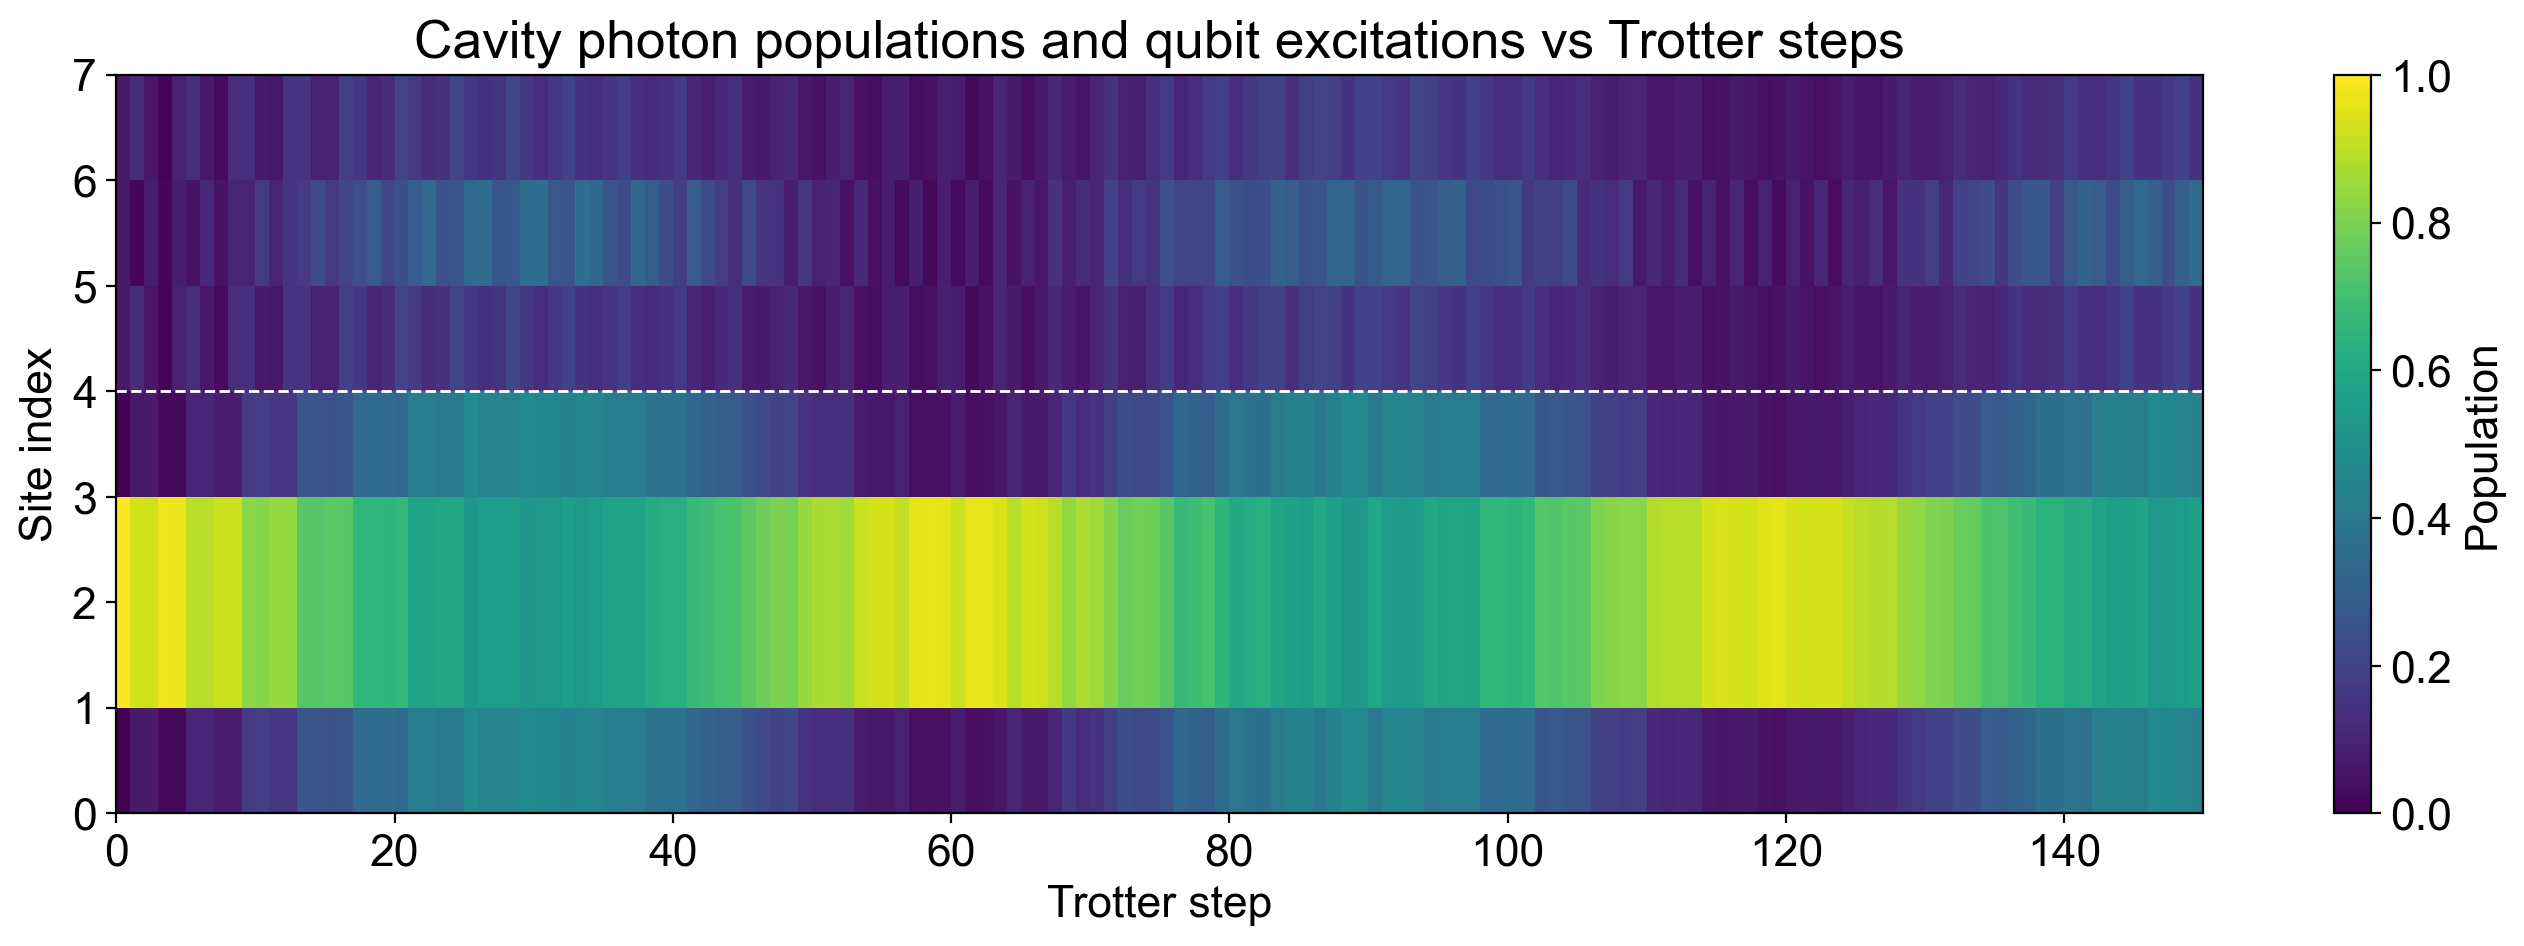

In [117]:
# Stack: first cavities, then qubits
pop_matrix = np.hstack([cavity_history, qubit_history])  # shape (steps, N_total + N_total-1)

steps = np.arange(1, pop_matrix.shape[0] + 1)
sites = np.arange(pop_matrix.shape[1])  # 0..(Nc+Nq-1)

# pcolormesh wants edges
X, Y = np.meshgrid(
    np.arange(len(steps)+1), 
    np.arange(len(sites)+1)
)

plt.figure(figsize=(14, 5))
pcm = plt.pcolormesh(X, Y, pop_matrix.T, shading='auto', cmap='viridis')
plt.colorbar(pcm, label="Population")

plt.xlabel("Trotter step")
plt.ylabel("Site index")
plt.title("Cavity photon populations and qubit excitations vs Trotter steps")

# Mark which y indices are cavities vs qubits
plt.axhline(y=cavity_history.shape[1], color='w', linestyle='--', linewidth=1)
plt.text(steps[-1]+0.3, cavity_history.shape[1]/2, "Cavities", va='center', color='w')
plt.text(steps[-1]+0.3, cavity_history.shape[1] + qubit_history.shape[1]/2, "Qubits", va='center', color='w')

plt.tight_layout()
plt.show()

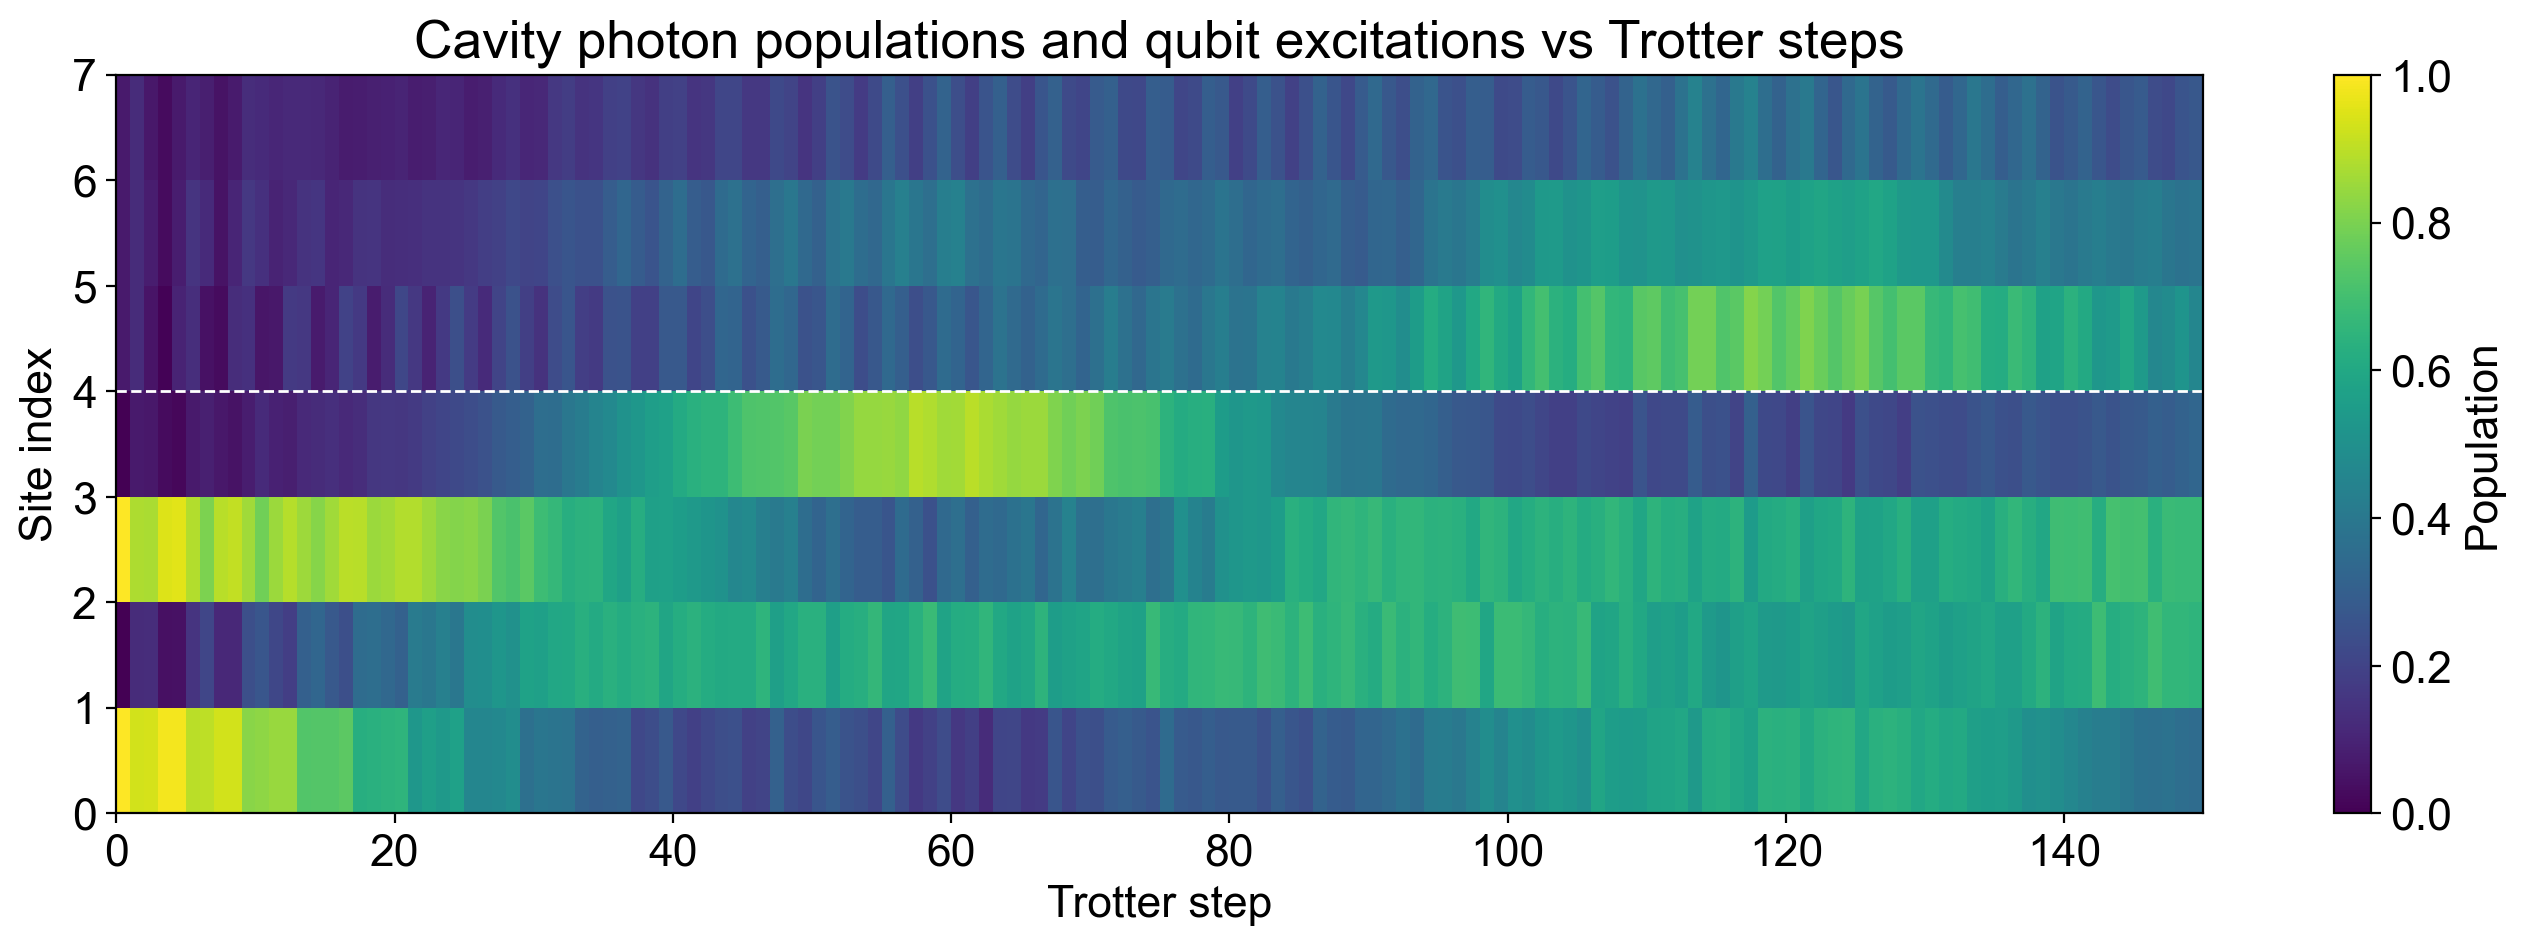

In [115]:
# Stack: first cavities, then qubits
pop_matrix = np.hstack([cavity_history, qubit_history])  # shape (steps, N_total + N_total-1)

steps = np.arange(1, pop_matrix.shape[0] + 1)
sites = np.arange(pop_matrix.shape[1])  # 0..(Nc+Nq-1)

# pcolormesh wants edges
X, Y = np.meshgrid(
    np.arange(len(steps)+1), 
    np.arange(len(sites)+1)
)

plt.figure(figsize=(14, 5))
pcm = plt.pcolormesh(X, Y, pop_matrix.T, shading='auto', cmap='viridis')
plt.colorbar(pcm, label="Population")

plt.xlabel("Trotter step")
plt.ylabel("Site index")
plt.title("Cavity photon populations and qubit excitations vs Trotter steps")

# Mark which y indices are cavities vs qubits
plt.axhline(y=cavity_history.shape[1], color='w', linestyle='--', linewidth=1)
plt.text(steps[-1]+0.3, cavity_history.shape[1]/2, "Cavities", va='center', color='w')
plt.text(steps[-1]+0.3, cavity_history.shape[1] + qubit_history.shape[1]/2, "Qubits", va='center', color='w')

plt.tight_layout()
plt.show()